# Live Anomaly Detector

## Imports

In [1]:
import sys
import pickle
import time
import threading

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

from src.monitor import collect_sample
from src.injector import create_payload_pool, run_exfiltration

import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## Helpers - Nice Printing

In [2]:
RESET = "\033[0m"
BOLD = "\033[1m"

RED = "\033[91m"
GREEN = "\033[92m"
YELLOW = "\033[93m"
CYAN = "\033[96m"
WHITE = "\033[97m"
GREY = "\033[90m"


def print_separator():
    print(CYAN + "=" * 110 + RESET)


def print_phase_header(phase_name, duration_s, expected_label):
    print_separator()
    print(CYAN + BOLD + "PHASE:" + RESET, CYAN + phase_name + RESET)
    print(
        CYAN + BOLD + "DURATION:" + RESET, CYAN + str(duration_s) + " seconds" + RESET
    )
    print(CYAN + BOLD + "EXPECTED:" + RESET, CYAN + expected_label + RESET)
    print_separator()


def format_mb_per_s(bytes_per_s):
    return float(bytes_per_s) / 1024.0 / 1024.0


def print_live_row(sample_index, phase_name, row):
    ts_unix = round(float(row["ts_unix"]), 3)

    disk_read = format_mb_per_s(row["disk_read_bytes_per_s"])
    disk_write = format_mb_per_s(row["disk_write_bytes_per_s"])
    disk_read_ops = float(row["disk_read_ops_per_s"])
    disk_write_ops = float(row["disk_write_ops_per_s"])

    net_sent = format_mb_per_s(row["net_bytes_sent_per_s"])
    net_recv = format_mb_per_s(row["net_bytes_recv_per_s"])
    net_sent_pkts = float(row["net_packets_sent_per_s"])
    net_recv_pkts = float(row["net_packets_recv_per_s"])

    disk_usage = float(row["disk_usage_percent_c"])

    print(
        WHITE
        + BOLD
        + "[SAMPLE "
        + str(sample_index).rjust(3, "0")
        + "] "
        + RESET
        + GREY
        + phase_name
        + RESET
    )

    print(
        "  "
        + GREY
        + "ts_unix="
        + RESET
        + str(ts_unix)
        + " | "
        + GREY
        + "disk_usage_percent_c="
        + RESET
        + f"{disk_usage:.2f}"
    )

    print(
        "  "
        + GREY
        + "disk_read_MBps="
        + RESET
        + f"{disk_read:.3f}"
        + " | "
        + GREY
        + "disk_write_MBps="
        + RESET
        + f"{disk_write:.3f}"
        + " | "
        + GREY
        + "disk_read_ops_per_s="
        + RESET
        + f"{disk_read_ops:.2f}"
        + " | "
        + GREY
        + "disk_write_ops_per_s="
        + RESET
        + f"{disk_write_ops:.2f}"
    )

    print(
        "  "
        + GREY
        + "net_sent_MBps="
        + RESET
        + f"{net_sent:.3f}"
        + " | "
        + GREY
        + "net_recv_MBps="
        + RESET
        + f"{net_recv:.3f}"
        + " | "
        + GREY
        + "net_packets_sent_per_s="
        + RESET
        + f"{net_sent_pkts:.2f}"
        + " | "
        + GREY
        + "net_packets_recv_per_s="
        + RESET
        + f"{net_recv_pkts:.2f}"
    )


def print_live_prediction(prediction):
    if prediction == 1:
        print("  " + RED + BOLD + "MODEL DECISION -> ANOMALY" + RESET)
    else:
        print("  " + GREEN + BOLD + "MODEL DECISION -> NORMAL" + RESET)

    print(GREY + "-" * 110 + RESET)

## Configurations
The runtime test is structured as:
baseline (20s) -> exfiltration (60s) -> baseline (20s)

In [3]:
RUN_ID = "20260307_163847"

MODEL_PATH = "../models/best_model_" + RUN_ID + ".pkl"
SCALER_PATH = "../models/scaler_" + RUN_ID + ".pkl"

BASELINE_DURATION = 20
INJECTION_DURATION = 60
SAMPLING_INTERVAL_S = 1.0

# VM
RECEIVER_HOST = "172.20.10.7"
RECEIVER_PORT = 5001

EXFIL_RATE_MBPS = 40.0
PAYLOAD_SIZE_MB = 800
PAYLOAD_COUNT = 5

FEATURE_COLUMNS = [
    "disk_read_bytes_per_s",
    "disk_write_bytes_per_s",
    "disk_read_ops_per_s",
    "disk_write_ops_per_s",
    "disk_usage_percent_c",
    "net_bytes_sent_per_s",
    "net_bytes_recv_per_s",
    "net_packets_sent_per_s",
    "net_packets_recv_per_s",
]

print("Run ID:", RUN_ID)
print("Baseline duration:", BASELINE_DURATION, "seconds")
print("Injection duration:", INJECTION_DURATION, "seconds")

Run ID: 20260307_163847
Baseline duration: 20 seconds
Injection duration: 60 seconds


## Load Model

In [4]:
def model_requires_scaling(model):
    # Only Logistic Regression & Local Outlier Factor require scaling,
    # so we ensure it is used only for those, if they were the best models
    model_name = type(model).__name__

    if model_name == "LogisticRegression":
        return True

    if model_name == "LocalOutlierFactor":
        return True

    return False


def load_model(model_path, scaler_path):
    with open(model_path, "rb") as file:
        model = pickle.load(file)

    scaler = None
    if model_requires_scaling(model):
        with open(scaler_path, "rb") as file:
            scaler = pickle.load(file)

    return model, scaler


def preprocess_sample(sample_row, scaler):
    # Turn single monitored row into the shape at inference time
    dataframe = pd.DataFrame([sample_row])
    X = dataframe[FEATURE_COLUMNS].astype(float).values

    if scaler is not None:
        X = scaler.transform(X)

    return X


def predict_label(model, X):
    # Supervised already returns following this pattern:
    #   normal -> 0
    #   anomaly -> 1
    #
    # For unsupervised on the other hand we have this pattern, which 
    # we convert to match supervised:
    #   normal -> 1 
    #   anomaly -> -1 
    model_name = type(model).__name__

    raw_prediction = model.predict(X)[0]

    if model_name == "IsolationForest":
        if raw_prediction == -1:
            return 1
        return 0

    if model_name == "LocalOutlierFactor":
        if raw_prediction == -1:
            return 1
        return 0

    return int(raw_prediction)


model, scaler = load_model(MODEL_PATH, SCALER_PATH)

print("Loaded model:", type(model).__name__)

Loaded model: RandomForestClassifier


## Live Inference

In [5]:
def collect(
    state,
    model,
    scaler,
    phase_name,
    total_duration,
    expected_label,
    next_sample_time,
):
    collection_start_time = time.time()

    # Keep information on collected data,
    # to ensure we can have some summarizations & visualizations later on
    rows = []
    predictions = []
    timestamps = []

    sample_index = 1

    print_phase_header(phase_name, total_duration, expected_label)

    while True:
        # Check if time is exhausted
        iteration_start_time = time.time()
        if iteration_start_time - collection_start_time >= total_duration:
            break

        # Address drift
        sleep_for = next_sample_time - time.time()
        if sleep_for > 0:
            time.sleep(sleep_for)

        # Collect & predict
        row = collect_sample(state)
        X = preprocess_sample(row, scaler)
        prediction = predict_label(model, X)

        # Add metadata
        rows.append(row)
        predictions.append(prediction)
        timestamps.append(float(row["ts_unix"]))

        print_live_row(sample_index, phase_name, row)
        print_live_prediction(prediction)

        sample_index = sample_index + 1
        next_sample_time = next_sample_time + SAMPLING_INTERVAL_S

    return {
        "phase": phase_name,
        "expected": expected_label,
        "rows": rows,
        "predictions": predictions,
        "timestamps": timestamps,
    }, next_sample_time


def run_live_test_sequence():
    state = {
        "prev_time": None,
        "prev_disk": None,
        "prev_net": None,
    }

    collect_sample(state)
    next_sample_time = time.time() + SAMPLING_INTERVAL_S

    # Prepare payloads before anomaly phase starts
    payload_paths = create_payload_pool(PAYLOAD_SIZE_MB, PAYLOAD_COUNT)

    all_results = []

    # Normal phase
    result, next_sample_time = collect(
        state=state,
        model=model,
        scaler=scaler,
        phase_name="baseline",
        total_duration=BASELINE_DURATION,
        expected_label="normal",
        next_sample_time=next_sample_time,
    )
    all_results.append(result)

    # Anomaly phase
    injection_result = {"entry": None}

    def injection_worker():
        entry = run_exfiltration(
            total_duration=INJECTION_DURATION,
            rate_mbs=EXFIL_RATE_MBPS,
            payload_paths=payload_paths,
            host=RECEIVER_HOST,
            port=RECEIVER_PORT,
        )
        injection_result["entry"] = entry

    injection_thread = threading.Thread(target=injection_worker, daemon=False)

    print_separator()
    print(YELLOW + BOLD + "Starting live exfiltration thread..." + RESET)
    print_separator()
    injection_thread.start()

    result, next_sample_time = collect(
        state=state,
        model=model,
        scaler=scaler,
        phase_name="exfiltration",
        total_duration=INJECTION_DURATION,
        expected_label="anomaly",
        next_sample_time=next_sample_time,
    )

    injection_thread.join()

    result["injection_log"] = injection_result["entry"]
    all_results.append(result)

    # Normal phase
    result, next_sample_time = collect(
        state=state,
        model=model,
        scaler=scaler,
        phase_name="baseline",
        total_duration=BASELINE_DURATION,
        expected_label="normal",
        next_sample_time=next_sample_time,
    )
    all_results.append(result)

    return all_results
    
print_separator()
print(BOLD + "Starting live anomaly detection test..." + RESET)
print_separator()

results = run_live_test_sequence()

print_separator()
print(BOLD + "Live test complete" + RESET)
print_separator()

Starting live anomaly detection test...
PHASE: baseline
DURATION: 20 seconds
EXPECTED: normal
[SAMPLE 001] baseline
  ts_unix=1773149489.258 | disk_usage_percent_c=35.20
  disk_read_MBps=0.302 | disk_write_MBps=0.209 | disk_read_ops_per_s=18.80 | disk_write_ops_per_s=13.86
  net_sent_MBps=0.001 | net_recv_MBps=0.000 | net_packets_sent_per_s=4.95 | net_packets_recv_per_s=2.97
  MODEL DECISION -> NORMAL
--------------------------------------------------------------------------------------------------------------
[SAMPLE 002] baseline
  ts_unix=1773149490.258 | disk_usage_percent_c=35.20
  disk_read_MBps=0.768 | disk_write_MBps=0.727 | disk_read_ops_per_s=36.00 | disk_write_ops_per_s=57.00
  net_sent_MBps=0.016 | net_recv_MBps=0.005 | net_packets_sent_per_s=4.00 | net_packets_recv_per_s=17.00
  MODEL DECISION -> NORMAL
--------------------------------------------------------------------------------------------------------------
[SAMPLE 003] baseline
  ts_unix=1773149491.258 | disk_usage_p

## Performance Summary

In [6]:
performance_rows = []

for result in results:
    phase_name = result["phase"]
    expected_label_name = result["expected"]
    predictions = result["predictions"]

    total_samples = len(predictions)
    anomaly_count = sum(predictions)
    normal_count = total_samples - anomaly_count

    if expected_label_name == "anomaly":
        correct = anomaly_count
        incorrect = normal_count
    else:
        correct = normal_count
        incorrect = anomaly_count

    accuracy = 0.0
    if total_samples > 0:
        accuracy = (correct / total_samples) * 100.0

    performance_rows.append(
        {
            "Phase": phase_name,
            "Expected": expected_label_name,
            "Total Samples": total_samples,
            "Predicted Normal": normal_count,
            "Predicted Anomaly": anomaly_count,
            "Accuracy (%)": round(accuracy, 1),
        }
    )

performance_df = pd.DataFrame(performance_rows)

baseline_df = performance_df[performance_df["Phase"].str.contains("baseline")]
anomaly_df = performance_df[performance_df["Phase"] == "exfiltration"]

print_separator()
print(BOLD + "RUNTIME PERFORMANCE SUMMARY" + RESET)
print_separator()
print(performance_df.to_string(index=False))

baseline_avg_accuracy = baseline_df["Accuracy (%)"].mean()
anomaly_accuracy = anomaly_df["Accuracy (%)"].mean()
overall_accuracy = performance_df["Accuracy (%)"].mean()

print_separator()
print("Baseline average accuracy:", round(baseline_avg_accuracy, 1), "%")
print("Anomaly phase accuracy:", round(anomaly_accuracy, 1), "%")
print("Overall phase average accuracy:", round(overall_accuracy, 1), "%")
print_separator()

RUNTIME PERFORMANCE SUMMARY
       Phase Expected  Total Samples  Predicted Normal  Predicted Anomaly  Accuracy (%)
    baseline   normal             20                20                  0         100.0
exfiltration  anomaly             60                 0                 60         100.0
    baseline   normal             21                21                  0         100.0
Baseline average accuracy: 100.0 %
Anomaly phase accuracy: 100.0 %
Overall phase average accuracy: 100.0 %


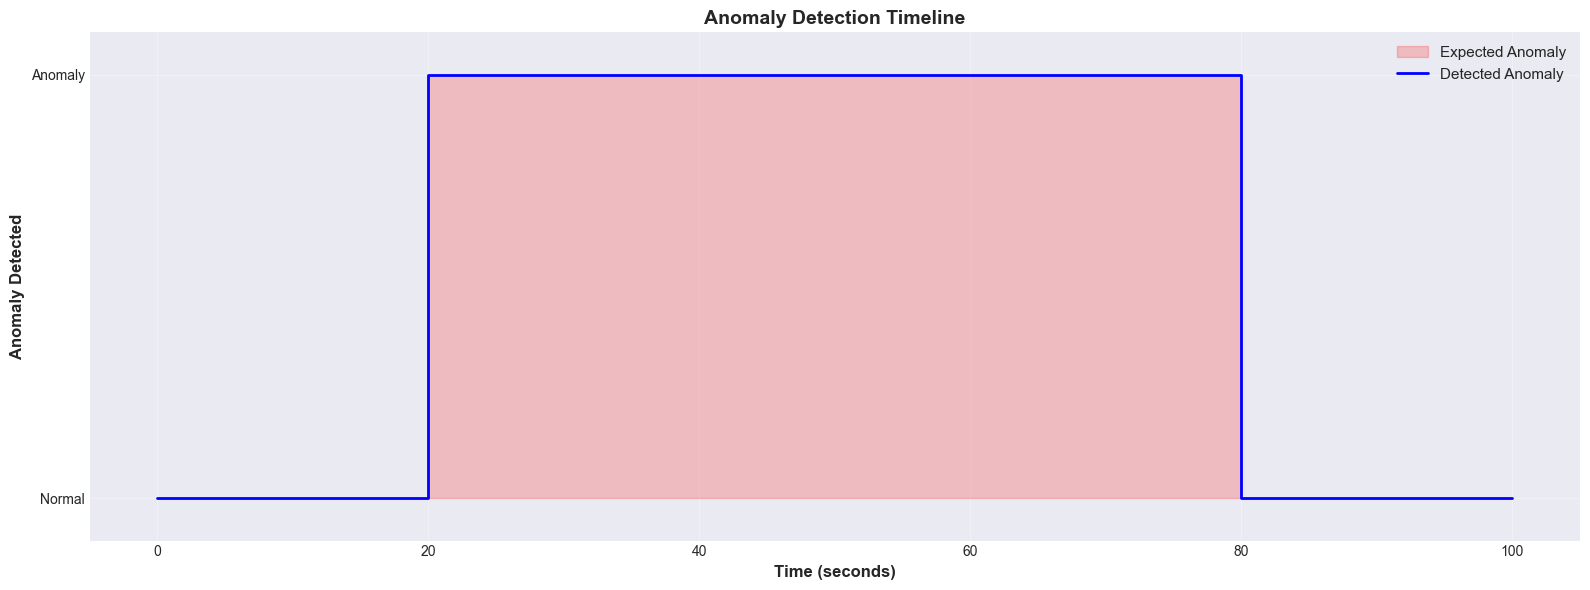

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))

all_timestamps = []
all_predictions = []
all_expected = []

collection_start_time = results[0]["timestamps"][0]

for result in results:
    timestamps = [(t - collection_start_time) for t in result["timestamps"]]
    predictions = result["predictions"]
    expected = [1 if result["expected"] == "anomaly" else 0] * len(predictions)

    all_timestamps.extend(timestamps)
    all_predictions.extend(predictions)
    all_expected.extend(expected)

ax.fill_between(
    all_timestamps,
    0,
    all_expected,
    alpha=0.2,
    color="red",
    label="Expected Anomaly",
    step="post",
)
ax.plot(
    all_timestamps,
    all_predictions,
    linewidth=2,
    color="blue",
    label="Detected Anomaly",
    drawstyle="steps-post",
)

ax.set_xlabel("Time (seconds)", fontsize=12, fontweight="bold")
ax.set_ylabel("Anomaly Detected", fontsize=12, fontweight="bold")
ax.set_title("Anomaly Detection Timeline", fontsize=14, fontweight="bold")
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Normal", "Anomaly"])
ax.legend(loc="upper right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()